In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from scipy import ndimage
from scipy.ndimage import map_coordinates, gaussian_filter

# k-Wave

from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.utils.signals import tone_burst

np.set_printoptions(suppress=True, precision=3)

# ---- paths ----
BRAIN_NII = r"C:\Users\bengi\Documents\Pesaran Lab\brain_mask.nii"

# ---- acoustics ----
freq      = 500e3                       # Hz  (lab standard)
c_brain, rho_brain = 1560.0, 1040.0
c_gel,   rho_gel   = 1000.0, 1030.0     # silicone (slow -> converging lens)
c_air     = 343.0                       # everything else outside brain
rho_air   = 100.0                       # STABILITY FLOOR 
P0        = 1e5                         # Pa, source pressure (100 kPa)
N_CYCLES  = 5                           # tone-burst cycles
SMOOTH_MED_VOX = 0.6                    # light Gaussian smoothing

# ---- grid ----
dx        = 0.5e-3                       # m  (= brain voxel size)

# ---- transducer placement ----
TX_DIAM   = 20e-3                        # flat transducer diameter (m)
HOLE_W    = 20e-3                        # craniotomy width  (along frame X) (m)
HOLE_L    = 30e-3                        # craniotomy length (along frame Y) (m)
STANDOFF  = 4e-3                         # m, reduced to 4mm so it's not zero, but very close

# (We will calculate MOUNT_FALLBACK and NORMAL_FALLBACK dynamically in Step 2)

# ---- static lens (Part 1) ----
FOCUS_DEPTH = 15e-3                      # m, desired focus depth BELOW the brain surface
FOCAL       = STANDOFF + FOCUS_DEPTH     # m, NOMINAL focal length 

# ---- frame extent ----
LAT_HALF    = 25e-3                      # m, half-width of the frame laterally (X,Y)
BRAIN_DEPTH = 42e-3                      # m, axial brain extent to include
Z_MARGIN    = 6                          # voxels of air before the transducer face

m2v = lambda m: m / dx                   # metres -> voxels (float)
lam_brain = c_brain / freq
lam_gel   = c_gel / freq
print(f"freq {freq/1e3:.0f} kHz | lambda brain {lam_brain*1e3:.2f} mm ({lam_brain/dx:.1f} pts), "
      f"gel {lam_gel*1e3:.2f} mm ({lam_gel/dx:.1f} pts)")
print(f"nominal focal length {FOCAL*1e3:.1f} mm  (= {STANDOFF*1e3:.0f} mm gel + {FOCUS_DEPTH*1e3:.0f} mm into brain)")
print(f"flat-transducer natural near field N = D^2/(4 lambda_brain) = {(TX_DIAM**2/(4*lam_brain))*1e3:.1f} mm")

c:\Users\bengi\miniconda3\envs\pesaranlab\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


freq 500 kHz | lambda brain 3.12 mm (6.2 pts), gel 2.00 mm (4.0 pts)
nominal focal length 19.0 mm  (= 4 mm gel + 15 mm into brain)
flat-transducer natural near field N = D^2/(4 lambda_brain) = 32.1 mm


In [2]:
# ---- Parameters ----
BRAIN_NII = r"C:\Users\bengi\Documents\Pesaran Lab\brain_mask.nii"
dx        = 0.5e-3                      
TX_DIAM   = 20e-3
HOLE_W    = 20e-3
HOLE_L    = 30e-3

# "Flat on top" -> no gel standoff
STANDOFF  = 0.0                        

# Facing straight down from the anatomical top (Crown). 
# Because the monkey's crown points to +i, the inward normal is -i.
NORMAL    = np.array([1.0, 0.0, 0.0])  


img   = nib.load(BRAIN_NII)
brain = img.get_fdata() > 0.5
brain = ndimage.binary_fill_holes(brain)                 # close interior gaps
brain = ndimage.binary_closing(brain, iterations=1)
NX, NY, NZ = brain.shape

axcodes = nib.aff2axcodes(img.affine)
C = np.argwhere(brain).mean(0)                           # centroid voxel

# anatomical unit vectors in VOXEL space  (i,j,k) -> (P, I, R)
S = np.array([0., -1.,  0.])   # superior  = -j
L = np.array([0.,  0., -1.])   # left      = -k
Pp = np.array([1.,  0.,  0.])  # posterior = +i

# --- NEW: Dynamically Find the Exact Top (Vertex) ---
# The anatomical crown points toward the +i axis in this scan.
i_coords = np.where(brain)[0]
i_top = i_coords.max()
top_slice = np.argwhere(brain[i_top-3:i_top, :, :])
j_top = top_slice[:, 1].mean()
k_top = top_slice[:, 2].mean()

# Update the fallback coordinates to the true crown, facing straight down
MOUNT_FALLBACK  = [i_top, j_top, k_top]
NORMAL_FALLBACK = [-1.0, 0.0, 0.0]

print(f"brain {brain.shape}  voxel axes -> {axcodes}  (expect P,I,R)")
print(f"brain voxels {brain.sum():,}  ({brain.sum()*dx**3*1e6:.1f} cm^3)")
print(f"centroid voxel {np.round(C,1)}")
print(f"Dynamically calculated crown (mount voxel): {np.round(MOUNT_FALLBACK, 1)}")

brain (256, 256, 208)  voxel axes -> ('P', 'I', 'R')  (expect P,I,R)
brain voxels 651,205  (81.4 cm^3)
centroid voxel [175.9 143.5 100.2]
Dynamically calculated crown (mount voxel): [221.  145.8  99.2]


TypeError: object of type 'float' has no len()

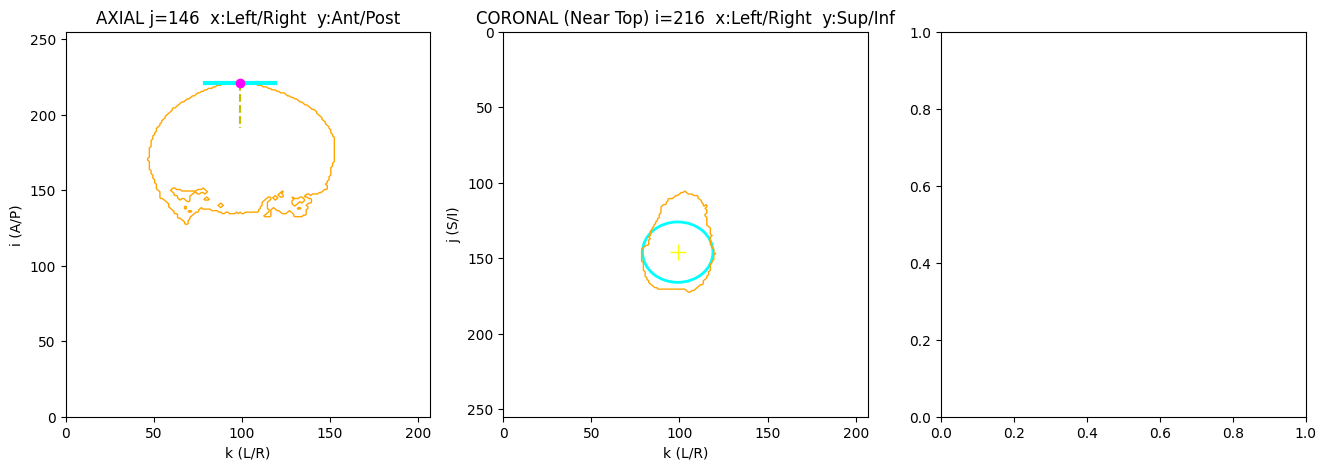

In [3]:
# --- Verification Plot ---
mx, my, mz = np.round(MOUNT_FALLBACK).astype(int)
tx_rad_vox = (TX_DIAM / 2) / dx
focus_depth_vox = 15e-3 / dx

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

color_brain = 'orange'
c_tx = '#00ffff'  # Cyan for visibility
c_beam = 'y--'
c_mount = 'magenta'

# 1. AXIAL (i-k plane): Sliced at j = my 
ax_axial = axes[0]
ax_axial.contour(brain[:, my, :], levels=[0.5], colors=color_brain, linewidths=1)
# Transducer line (flat on top along i=mx)
ax_axial.plot([mz - tx_rad_vox, mz + tx_rad_vox], [mx, mx], color=c_tx, lw=3)
# Beam line (straight down along i)
ax_axial.plot([mz, mz], [mx, mx - focus_depth_vox], c_beam)
ax_axial.plot(mz, mx, marker='o', color=c_mount, ms=6)
ax_axial.set(title=f"AXIAL j={my}  x:Left/Right  y:Ant/Post", xlabel="k (L/R)", ylabel="i (A/P)")

# 2. CORONAL (j-k plane): Sliced just inside the brain to see the outline (i = mx - 5)
ax_coronal = axes[1]
slice_i = mx - 5 
ax_coronal.contour(brain[slice_i, :, :], levels=[0.5], colors=color_brain, linewidths=1)
# Transducer is a CIRCLE in this plane, parallel to the surface
circle = plt.Circle((mz, my), tx_rad_vox, color=c_tx, fill=False, lw=2)
ax_coronal.add_patch(circle)
ax_coronal.plot(mz, my, marker='+', color='yellow', ms=12) # Beam going straight into screen
ax_coronal.set(title=f"CORONAL (Near Top) i={slice_i}  x:Left/Right  y:Sup/Inf", xlabel="k (L/R)", ylabel="j (S/I)")
ax_coronal.invert_yaxis()

# 3. SAGITTAL (i-j plane): Sliced at k = mz
ax_sagittal = axes[2]
ax_sagittal.contour(brain[:, :, mz].T, levels=[0.5], colors=c_brain, linewidths=1)
# Transducer line (flat on top along i=mx)
ax_sagittal.plot([mx, mx], [my - tx_rad_vox, my + tx_rad_vox], color=c_tx, lw=3)
# Beam line (straight down along i)
ax_sagittal.plot([mx, mx - focus_depth_vox], [my, my], c_beam)
ax_sagittal.plot(mx, my, marker='o', color=c_mount, ms=6)
ax_sagittal.set(title=f"SAGITTAL k={mz}  x:Ant/Post  y:Sup/Inf", xlabel="i (A/P)", ylabel="j (S/I)")
ax_sagittal.invert_yaxis()

for ax in axes:
    ax.set_facecolor('black')
    ax.set_aspect('equal')

plt.suptitle("Transducer Setup Verification: Flat on True Crown, Straight Down", color='white', y=1.05)
fig.patch.set_facecolor('black')
for text in fig.texts: text.set_color('white')
for ax in axes:
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

plt.tight_layout()
plt.show()

In [6]:
# --- transducer placement: FORCE fallback to use the calculated true crown ---
import os, json
# I have commented this out so it strictly uses the flat/top placement 
# rather than pulling old angled data from your local file.
# if os.path.exists("transducer_location.json"):
#    loc = json.load(open("transducer_location.json"))
#    ...
# else:

entry = np.array(MOUNT_FALLBACK, float)
n_out = np.array(NORMAL_FALLBACK, float)
n_out /= np.linalg.norm(n_out)

# report equivalent angles + anatomical offset (sanity)
aLd = np.degrees(np.arcsin(np.clip(n_out@L, -1, 1)))
aPd = np.degrees(np.arcsin(np.clip((n_out@Pp)/max(np.cos(np.radians(aLd)),1e-6), -1, 1)))
d = (entry - C)*dx*1e3
print(f"beam normal {np.round(n_out,3)}  (~{aLd:+.0f} deg left, {aPd:+.0f} deg back from vertex)")
print(f"mount offset from centroid: {abs(d@L):.0f}mm {'L' if d@L>0 else 'R'}, "
      f"{abs(d@Pp):.0f}mm {'Post' if d@Pp>0 else 'Ant'}, {abs(d@S):.0f}mm {'Sup' if d@S>0 else 'Inf'}")

# --- transducer frame basis (e_z = inward beam) ---
e_z = -n_out
e_x = L - (L @ e_z)*e_z;  e_x /= np.linalg.norm(e_x)      # ~ anatomical-left, in-plane
e_y = np.cross(e_z, e_x)

# --- frame grid sizes (voxels) ---
nlat   = int(round(m2v(LAT_HALF)))
Nxf = Nyf = 2*nlat
z_tx   = Z_MARGIN
z_surf = z_tx + int(round(m2v(STANDOFF)))                 # nominal surface depth in frame
Nzf    = z_surf + int(round(m2v(BRAIN_DEPTH))) + Z_MARGIN
cx = cy = Nxf // 2

# frame origin in brain-voxel coords so that frame(cx,cy,z_surf) == entry
O = entry - cx*e_x - cy*e_y - z_surf*e_z

# --- resample brain mask into the frame ---
gx, gy, gz = np.meshgrid(np.arange(Nxf), np.arange(Nyf), np.arange(Nzf), indexing="ij")
coords = (O[:,None,None,None]
          + gx[None]*e_x[:,None,None,None]
          + gy[None]*e_y[:,None,None,None]
          + gz[None]*e_z[:,None,None,None])
brain_f = map_coordinates(brain.astype(np.float32), coords, order=0, mode="constant") > 0.5
del gx, gy, gz, coords

print(f"frame {Nxf} x {Nyf} x {Nzf}  ({Nxf*dx*1e3:.0f} x {Nyf*dx*1e3:.0f} x {Nzf*dx*1e3:.0f} mm)")
print(f"transducer face plane z_tx = {z_tx} ({z_tx*dx*1e3:.1f} mm); nominal surface z = {z_surf} ({z_surf*dx*1e3:.1f} mm)")
print(f"brain voxels in frame {brain_f.sum():,}  ({100*brain_f.mean():.1f}% of box)")

beam normal [-1.  0.  0.]  (~+0 deg left, -90 deg back from vertex)
mount offset from centroid: 1mm L, 23mm Post, 1mm Inf
frame 100 x 100 x 96  (50 x 50 x 48 mm)
transducer face plane z_tx = 6 (3.0 mm); nominal surface z = 6 (3.0 mm)
brain voxels in frame 8,623  (0.9% of box)


In [12]:
# --- Setup Homogeneous Grid ---
Nxf_h = Nyf_h = int(round(m2v(25e-3))) * 2  # 50mm lateral frame
Nzf_h = int(round(m2v(STANDOFF + FOCUS_DEPTH + 15e-3))) + 12 # Cover focal depth + margin
cx_h = cy_h = Nxf_h // 2
z_tx_h = 6  # Transducer plane

# --- Generate Lens Thickness Profile ---
fx, fy = np.meshgrid(np.arange(Nxf_h), np.arange(Nyf_h), indexing="ij")
R2 = np.sqrt(((fx - cx_h)*dx)**2 + ((fy - cy_h)*dx)**2)
disc = R2 <= (TX_DIAM / 2)

# Straight-line travel time element(radius) -> focus
Lpath = np.sqrt(R2**2 + FOCAL**2)
frac_gel = STANDOFF / FOCAL
Lgel = Lpath * frac_gel
Lbr = Lpath - Lgel
c_g = float(np.atleast_1d(c_gel)[0])
c_b = float(np.atleast_1d(c_brain)[0])
tt = np.float64(Lgel) / c_g + np.float64(Lbr) / c_b

delay = np.where(disc, np.float64(tt[disc].max()) - np.float64(tt), 0.0)
lens_thick = np.where(disc, np.float64(delay) / (1/c_g - 1/c_b), 0.0)

# --- Build Homogeneous Medium ---
tissue_h = np.full((Nxf_h, Nyf_h, Nzf_h), 2, dtype=np.uint8) # Default to brain/water
zg_h = np.broadcast_to(np.arange(Nzf_h), (Nxf_h, Nyf_h, Nzf_h))
# Insert Gel layer based on calculated thickness
gel_mask_h = disc[:,:,None] & (zg_h >= z_tx_h) & ((zg_h - z_tx_h)*dx < lens_thick[:,:,None])
tissue_h[gel_mask_h] = 1

c_map_h   = np.where(tissue_h == 1, c_gel, c_brain).astype(np.float32)
rho_map_h = np.where(tissue_h == 1, rho_gel, rho_brain).astype(np.float32)

# --- Source & Sim ---
tx_mask_h = np.zeros((Nxf_h, Nyf_h, Nzf_h), np.uint8)
tx_mask_h[:, :, z_tx_h] = disc

kgrid_h = kWaveGrid([Nxf_h, Nyf_h, Nzf_h], [dx, dx, dx])
kgrid_h.makeTime(c_brain, cfl=0.3, t_end=1.25 * (Nzf_h*dx) / c_gel)
medium_h = kWaveMedium(sound_speed=c_map_h, density=rho_map_h)

xs, ys, zs = np.where(tx_mask_h > 0)
lin_F = np.ravel_multi_index((xs, ys, zs), tx_mask_h.shape, order="F")
perm = np.argsort(lin_F)
xs, ys = xs[perm], ys[perm]

base = tone_burst(1/kgrid_h.dt, freq, N_CYCLES).flatten()
shift = np.round(delay[xs, ys] / kgrid_h.dt).astype(int)
sig = np.zeros((len(xs), kgrid_h.Nt), np.float32)
for k, s in enumerate(shift):
    n = min(len(base), kgrid_h.Nt - s)
    if n > 0: sig[k, s:s+n] = base[:n]

source_h = kSource()
source_h.p_mask = tx_mask_h
source_h.p = P0 * sig

sensor_h = kSensor()
sensor_h.mask = np.ones((Nxf_h, Nyf_h, Nzf_h), np.uint8)
sensor_h.record = ["p_max"]

print("Running homogeneous forward sim (GPU)...")
sd_h = kspaceFirstOrder(kgrid_h, medium_h, source_h, sensor_h, device="gpu", dtype="float32")

p_max_h = np.zeros((Nxf_h, Nyf_h, Nzf_h), np.float32)
p_max_h[sensor_h.mask.astype(bool)] = np.squeeze(np.asarray(sd_h["p_max"]))
fi_h = np.unravel_index(np.argmax(p_max_h), p_max_h.shape)
print(f"Focal depth from transducer: {(fi_h[2] - z_tx_h)*dx*1e3:.1f} mm (Design: {FOCAL*1e3:.1f} mm)")

Running homogeneous forward sim (GPU)...


k-Wave: 100%|██████████| 522/522 [00:04<00:00, 125.93step/s]


Focal depth from transducer: 2.5 mm (Design: 19.0 mm)


In [14]:
# --- Load & Clean Brain ---
BRAIN_NII = r"C:\Users\bengi\Documents\Pesaran Lab\brain_mask.nii"
img = nib.load(BRAIN_NII)
brain = img.get_fdata() > 0.5
brain = ndimage.binary_fill_holes(brain)
brain = ndimage.binary_closing(brain, iterations=1)

# Anatomical vectors
S, L, Pp = np.array([0., -1., 0.]), np.array([0., 0., -1.]), np.array([1., 0., 0.])

# --- Transducer Frame ---
entry = np.array(MOUNT_FALLBACK, float)
n_out = np.array(NORMAL, float)
n_out /= np.linalg.norm(n_out)

e_z = -n_out
e_x = L - (L @ e_z)*e_z
e_x /= np.linalg.norm(e_x)
e_y = np.cross(e_z, e_x)

Nxf = Nyf = Nxf_h
z_tx = z_tx_h
z_surf = z_tx + int(round(m2v(STANDOFF)))
Nzf = z_surf + int(round(m2v(42e-3))) + 6 # Brain depth + margin
cx = cy = Nxf // 2

O = entry - cx*e_x - cy*e_y - z_surf*e_z

gx, gy, gz = np.meshgrid(np.arange(Nxf), np.arange(Nyf), np.arange(Nzf), indexing="ij")
coords = (O[:,None,None,None] + gx[None]*e_x[:,None,None,None] + 
          gy[None]*e_y[:,None,None,None] + gz[None]*e_z[:,None,None,None])
brain_f = map_coordinates(brain.astype(np.float32), coords, order=0, mode="constant") > 0.5
del gx, gy, gz, coords

In [15]:
# --- Tissue Map & Air Boundaries ---
surf = np.full((Nxf, Nyf), Nzf, int)
anyb = brain_f.any(2)
surf[anyb] = brain_f.argmax(2)[anyb]

# Elliptical craniotomy footprint
X2 = (fx - cx)*dx; Y2 = (fy - cy)*dx
in_hole = ((X2/(HOLE_W/2))**2 + (Y2/(HOLE_L/2))**2) <= 1.0

zg = np.broadcast_to(np.arange(Nzf), (Nxf, Nyf, Nzf))

# Everything outside brain is air initially
tissue = np.zeros((Nxf, Nyf, Nzf), np.uint8) 

# Insert the exact lens profile calculated in Phase 1
gel_lens = disc[:,:,None] & (zg >= z_tx) & ((zg - z_tx)*dx < lens_thick[:,:,None])
tissue[gel_lens] = 1

# Insert bulk coupling gel (filling the hole down to the brain)
gel_bulk = in_hole[:,:,None] & (zg >= z_tx) & (zg < surf[:,:,None]) & ~brain_f
tissue[gel_bulk] = 1

# Insert brain
tissue[brain_f] = 2

c_map   = np.full((Nxf, Nyf, Nzf), c_air,   np.float32)
rho_map = np.full((Nxf, Nyf, Nzf), rho_air, np.float32)
c_map[tissue==1], rho_map[tissue==1] = c_gel,   rho_gel
c_map[tissue==2], rho_map[tissue==2] = c_brain, rho_brain

# Smooth interfaces for stability
c_map   = gaussian_filter(c_map, 0.6).astype(np.float32)
rho_map = gaussian_filter(rho_map, 0.6).astype(np.float32)

# --- Source & Sim ---
tx_mask = np.zeros((Nxf, Nyf, Nzf), np.uint8)
tx_mask[:, :, z_tx] = disc

kgrid = kWaveGrid([Nxf, Nyf, Nzf], [dx, dx, dx])
kgrid.makeTime(c_brain, cfl=0.3, t_end=1.25 * (Nzf*dx) / c_gel)
medium = kWaveMedium(sound_speed=c_map, density=rho_map)

# We can reuse the `sig` from the homogeneous run since the physical lens/delays are identical
source = kSource()
source.p_mask = tx_mask
source.p = P0 * sig

sensor = kSensor()
sensor.mask = np.ones((Nxf, Nyf, Nzf), np.uint8)
sensor.record = ["p_max"]

print("Running full brain forward sim (GPU)...")
sd = kspaceFirstOrder(kgrid, medium, source, sensor, device="gpu", dtype="float32")

p_max = np.zeros((Nxf, Nyf, Nzf), np.float32)
p_max[sensor.mask.astype(bool)] = np.squeeze(np.asarray(sd["p_max"]))

pm_brain = np.nan_to_num(np.where(brain_f, p_max, 0.0))
fi = np.unravel_index(np.argmax(pm_brain), pm_brain.shape)
print(f"FOCUS in Brain at voxel {fi}")
print(f"Depth below brain surface: {(fi[2] - surf[fi[0], fi[1]])*dx*1e3:.1f} mm")

Running full brain forward sim (GPU)...


k-Wave: 100%|██████████| 678/678 [00:06<00:00, 104.39step/s]


FOCUS in Brain at voxel (np.int64(50), np.int64(50), np.int64(12))
Depth below brain surface: 6.0 mm


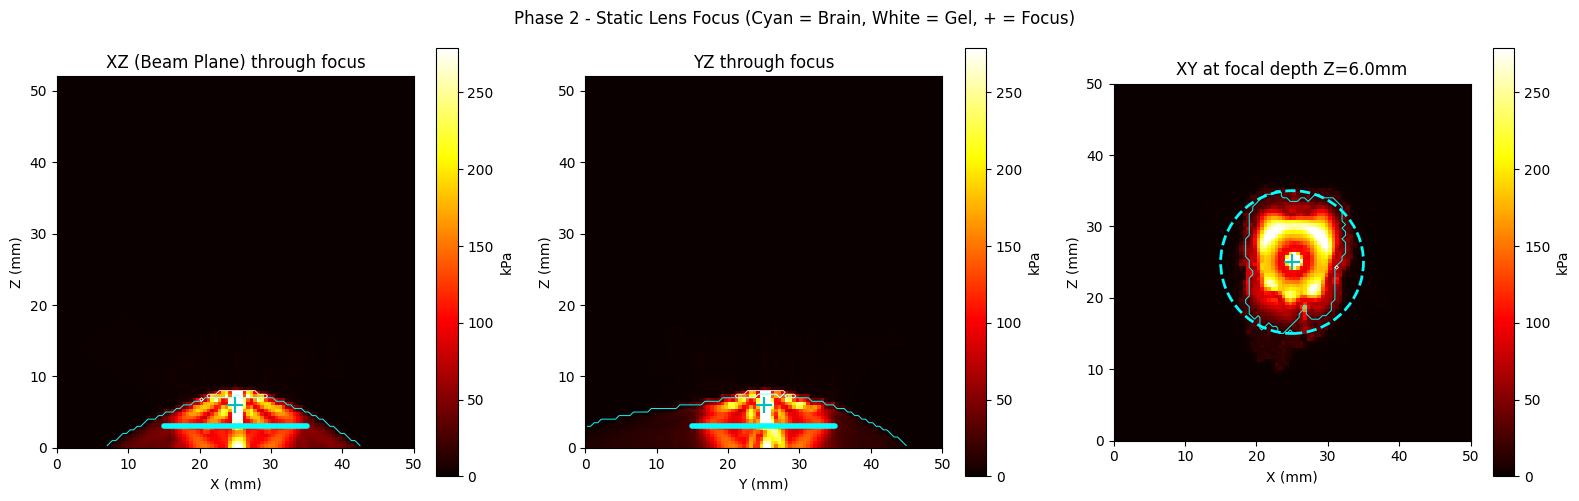

In [17]:
# --- Visualize Peak Pressure Through the Focus ---
# Converts the focal voxel indices (fi) to physical coordinates (mm)
fx_mm, fy_mm, fz_mm = np.array(fi) * dx * 1e3

# Set up physical extents for the plots (in mm)
ex = [0, Nxf * dx * 1e3]
ey = [0, Nyf * dx * 1e3]
ez = [0, Nzf * dx * 1e3]

# Cap the color map at the 99.8th percentile inside the brain to avoid bright local artifacts
vmax = np.percentile(p_max[brain_f], 99.8) / 1e3 if brain_f.sum() > 0 else p_max.max() / 1e3

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Define the slices to plot: (data, extent, title, target_x, target_y, brain_slice, tissue_slice)
panels = [
    (p_max[:, fi[1], :].T / 1e3, ex + ez, "XZ (Beam Plane) through focus", fx_mm, fz_mm, brain_f[:, fi[1], :].T, tissue[:, fi[1], :].T),
    (p_max[fi[0], :, :].T / 1e3, ey + ez, "YZ through focus", fy_mm, fz_mm, brain_f[fi[0], :, :].T, tissue[fi[0], :, :].T),
    (p_max[:, :, fi[2]].T / 1e3, ex + ey, f"XY at focal depth Z={fz_mm:.1f}mm", fx_mm, fy_mm, brain_f[:, :, fi[2]].T, tissue[:, :, fi[2]].T)
]

for a, (d, ext, ti, px, py, b_slice, t_slice) in zip(axes, panels):
    # Plot the pressure field
    im = a.imshow(d, origin="lower", extent=ext, cmap="hot", vmin=0, vmax=vmax)
    
    # Overlay brain boundary (cyan)
    a.contour(b_slice.astype(float), levels=[0.5], colors="cyan", linewidths=0.7, extent=ext, origin="lower")
    
    # Overlay gel boundary (white)
    a.contour((t_slice == 1).astype(float), levels=[0.5], colors="white", linewidths=0.6, extent=ext, origin="lower")
    
    # Mark the focal peak
    a.plot(px, py, "c+", ms=12, mew=1.5)
    
    a.set(title=ti, xlabel="X (mm)" if "X" in ti else "Y (mm)", ylabel="Z (mm)" if "Z" in ti else "Y (mm)")
    plt.colorbar(im, ax=a, label="kPa")

# --- Add Transducer Overlays ---
# Convert transducer center and radius to mm
cx_mm = cx * dx * 1e3
cy_mm = cy * dx * 1e3
ztx_mm = z_tx * dx * 1e3
r_mm = (TX_DIAM / 2) * 1e3

# 1. XZ Plane (axes[0]): Transducer is a line across X at depth z_tx
axes[0].plot([cx_mm - r_mm, cx_mm + r_mm], [ztx_mm, ztx_mm], color='#00ffff', linewidth=4, solid_capstyle='round')

# 2. YZ Plane (axes[1]): Transducer is a line across Y at depth z_tx
axes[1].plot([cy_mm - r_mm, cy_mm + r_mm], [ztx_mm, ztx_mm], color='#00ffff', linewidth=4, solid_capstyle='round')

# 3. XY Plane (axes[2]): Draw the circular footprint of the transducer for reference
circle = plt.Circle((cx_mm, cy_mm), r_mm, color='#00ffff', fill=False, linewidth=2, linestyle='--')
axes[2].add_patch(circle)

plt.suptitle("Phase 2 - Static Lens Focus (Cyan = Brain, White = Gel, + = Focus)")
plt.tight_layout()
plt.show()